Reddit Post NFSW Classification Project

Importing the necessary libararies

In [ ]:
!pip install pandasql

In [2]:
import numpy as np
import pandas as pd
import spacy
import nltk
import re
import json
from nltk.corpus import stopwords
import pandas as pd
from pandasql import sqldf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report

Reading Data and Initial Exploration

In [3]:
df = pd.read_csv("data/r_dataisbeautiful_posts.csv")
print("The data shape is:", df.shape)
df.head(10)

The data shape is: (193091, 12)


/tmp/ipykernel_20425/951148769.py:1: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("r_dataisbeautiful_posts.csv")


,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,it7yz2,[OC] The World’s Forests Mapped,1,vividmaps,NaN,NaN,0.0,[],1600173678,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
1,it7uig,[OC] Airbnb presence mapped in Barcelona (BCN)...,1,JonnieNeptune,OC: 2,NaN,0.0,[],1600173208,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
2,it7t4z,A marketplace for open streaming data sources,1,DangerMouse289,NaN,automod_filtered,0.0,[],1600173075,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
3,it7jfq,[OC] Black Owner-Occupied Housing,1,SocialExplorerInc,OC: 17,NaN,0.0,[],1600172010,https://www.reddit.com/r/dataisbeautiful/comme...,1,False
4,it7a3r,[OC] My monthly average steps in 2020. Quarant...,1,ahmedgelemli,OC: 2,NaN,0.0,[],1600171002,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
5,it6zcg,[OC] #covid19 US county map animation,1,graphguy,OC: 11,NaN,0.0,[],1600169727,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
6,it6rer,bibo vs shark,1,Samir_hambli,NaN,moderator,0.0,[],1600168753,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
7,it6pdc,Here’s a map of the my toddlers decision makin...,1,Kavbastyrd,NaN,NaN,0.0,[],1600168480,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
8,it6mvj,[OC] Types of fuels used in cars in Belgium (2...,1,Orvall,NaN,NaN,0.0,[],1600168138,https://www.reddit.com/r/dataisbeautiful/comme...,0,False
9,it6m5t,Here’s a map of the my toddlers decision makin...,1,Kavbastyrd,NaN,moderator,0.0,[],1600168038,https://www.reddit.com/r/dataisbeautiful/comme...,1,False


In [4]:
df.describe()

,score,total_awards_received,created_utc,num_comments
count,193091.000000,53239.000000,1.930910e+05,193091.000000
mean,180.261157,0.005898,1.501766e+09,26.374502
std,1946.307188,0.241624,6.569719e+07,206.886930
min,0.000000,0.000000,1.329263e+09,0.000000
25%,1.000000,0.000000,1.449986e+09,1.000000
50%,1.000000,0.000000,1.502211e+09,1.000000
75%,4.000000,0.000000,1.561930e+09,4.000000
max,116226.000000,30.000000,1.600174e+09,18801.000000


In [5]:
df.isnull().sum()

,0
id,0
title,1
score,0
author,0
author_flair_text,166218
removed_by,177406
total_awards_received,139852
awarders,150523
created_utc,0
full_link,0


Basic information:
The data shape is 1,93,091,i.e. 193k rows are there. This is moderately big dataset.

So the reddit data has the following columns:

(1) id: this represents a unique id for each post.

(2) title: each reddit post contains a title, this is the title text.

(3) score: each reddit post can be upvoted or downvoted. And thereby receives a score. This is that score.

(4) author: this is basically user name.

(5) author_flair_text: Need to know exactly what does it represent. We will inspect the data first and check in other notebooks too.

(6) removed_by: this is removed by what option. i.e. if the post is eventually removed, who removed it. This is a very interesting source of data.

(7) created_utc: when was this post created in utc timing but it is in unix epoch format. We need to transform it into normal date time to work on it.

(8) full_link: what is the full_link for the reddit post. This url will contain reddit's domain, subreddit and other informations. Need to parse the link to create subreddit and other different informations.

(9)num_comments: this is total number of comments which were seen in the post.

(10) over_18: this is basically the NSFW tag in reddit. Denotes whether the post contains something adult or not.

Performing EDA using Panda-SQL Library

In [6]:
pysqldf = lambda q: sqldf(q, globals())

In [7]:
# Just Reading the data using psql
q1 = "SELECT * FROM df LIMIT 10;"
pysqldf(q1)

,id,title,score,author,author_flair_text,removed_by,total_awards_received,awarders,created_utc,full_link,num_comments,over_18
0,it7yz2,[OC] The World’s Forests Mapped,1,vividmaps,None,None,0.0,[],1600173678,https://www.reddit.com/r/dataisbeautiful/comme...,1,0
1,it7uig,[OC] Airbnb presence mapped in Barcelona (BCN)...,1,JonnieNeptune,OC: 2,None,0.0,[],1600173208,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
2,it7t4z,A marketplace for open streaming data sources,1,DangerMouse289,None,automod_filtered,0.0,[],1600173075,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
3,it7jfq,[OC] Black Owner-Occupied Housing,1,SocialExplorerInc,OC: 17,None,0.0,[],1600172010,https://www.reddit.com/r/dataisbeautiful/comme...,1,0
4,it7a3r,[OC] My monthly average steps in 2020. Quarant...,1,ahmedgelemli,OC: 2,None,0.0,[],1600171002,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
5,it6zcg,[OC] #covid19 US county map animation,1,graphguy,OC: 11,None,0.0,[],1600169727,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
6,it6rer,bibo vs shark,1,Samir_hambli,None,moderator,0.0,[],1600168753,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
7,it6pdc,Here’s a map of the my toddlers decision makin...,1,Kavbastyrd,None,None,0.0,[],1600168480,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
8,it6mvj,[OC] Types of fuels used in cars in Belgium (2...,1,Orvall,None,None,0.0,[],1600168138,https://www.reddit.com/r/dataisbeautiful/comme...,0,0
9,it6m5t,Here’s a map of the my toddlers decision makin...,1,Kavbastyrd,None,moderator,0.0,[],1600168038,https://www.reddit.com/r/dataisbeautiful/comme...,1,0


In [8]:
#Count of Posts per author
q2 = """
SELECT author, COUNT(*) AS total_posts
FROM df
GROUP BY author
ORDER BY total_posts DESC;
"""
pysqldf(q2)

,author,total_posts
0,[deleted],29285
1,jimrosenz,2303
2,OverflowDs,485
3,rhiever,327
4,RAGTIMEMA,325
...,...,...
82562,--Kebab_Remover--,1
82563,--Julius,1
82564,---sniff---,1
82565,---andrew,1


In [9]:
#Average score per author flair
q3 = """
SELECT author_flair_text, AVG(score) AS avg_score, COUNT(*) AS num_posts
FROM df
WHERE author_flair_text IS NOT NULL
GROUP BY author_flair_text
ORDER BY avg_score DESC;
"""
pysqldf(q3)

,author_flair_text,avg_score,num_posts
0,OC: 137,27954.500000,2
1,OC: 98,14972.000000,1
2,OC: 86,8750.000000,9
3,OC: 85,6984.428571,7
4,OC: 102,6575.000000,1
...,...,...,...
190,OC: 116,1.000000,1
191,OC: 115,1.000000,3
192,OC: 112,1.000000,1
193,Martín González and Evan Henſleigh,1.000000,1


In [10]:
# Posts with above-average score (CTE example)
q4 = """
WITH avg_score_cte AS (
    SELECT AVG(score) AS avg_score FROM df
)
SELECT id, title, author, score
FROM df, avg_score_cte
WHERE score > avg_score_cte.avg_score
ORDER BY score DESC;
"""
pysqldf(q4)

,id,title,author,score
0,7elwve,Imagine having to pay money to share your data...,MOSTEPICPLAYER,116226
1,b5f9wi,Let's hear it for the lurkers! The vast majori...,TrueBirch,105255
2,8cwcbu,Cause of Death - Reality vs. Google vs. Media ...,aaronpenne,101451
3,8bzdr8,Gaze and foot placement when walking over roug...,sandusky_hohoho,99611
4,dbntq8,"Light Speed – fast, but slow [OC]",physicsJ,92686
...,...,...,...,...
7118,1u0r35,VisaMapper,daho123,181
7119,1fhctt,The changing number of nations 1800-2010 [OC],shivasprogeny,181
7120,1ecpcw,Naming of Rivers in Britain,[deleted],181
7121,19jeb9,Italian elections results of the lower house. ...,Areat,181


In [11]:
#Distribution of NSFW (over_18) posts

q5 = """
SELECT over_18, COUNT(*) AS post_count,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM df), 2) AS percent
FROM df
GROUP BY over_18;
"""
pysqldf(q5)

,over_18,post_count,percent
0,0,192094,99.48
1,1,997,0.52


In [12]:
# Total posts removed + percentage by moderator
q6a = """
WITH total_posts AS (
    SELECT COUNT(*) AS total_count FROM df
),
removed_summary AS (
    SELECT
        removed_by,
        COUNT(*) AS total_removed
    FROM df
    WHERE removed_by IS NOT NULL
    GROUP BY removed_by
)
SELECT
    r.removed_by,
    r.total_removed,
    ROUND(100.0 * r.total_removed / t.total_count, 2) AS percent_removed
FROM removed_summary r, total_posts t
ORDER BY percent_removed DESC;
"""
pysqldf(q6a)

,removed_by,total_removed,percent_removed
0,moderator,11036,5.72
1,deleted,2398,1.24
2,automod_filtered,1187,0.61
3,reddit,1063,0.55
4,author,1,0.00


In [13]:
#NSFW vs SFW deletion distribution
q6b = """
WITH deletion_stats AS (
    SELECT
        over_18,
        CASE WHEN removed_by IS NOT NULL THEN 'Deleted' ELSE 'Not Deleted' END AS deletion_status,
        COUNT(*) AS post_count
    FROM df
    GROUP BY over_18, deletion_status
),
total_counts AS (
    SELECT SUM(post_count) AS total_posts FROM deletion_stats
)
SELECT
    d.over_18,
    d.deletion_status,
    d.post_count,
    ROUND(100.0 * d.post_count / t.total_posts, 2) AS percent_of_total
FROM deletion_stats d, total_counts t
ORDER BY d.over_18, d.deletion_status;
"""
pysqldf(q6b)

,over_18,deletion_status,post_count,percent_of_total
0,0,Deleted,15595,8.08
1,0,Not Deleted,176499,91.41
2,1,Deleted,90,0.05
3,1,Not Deleted,907,0.47


In [14]:
#Top posts by number of comments (Window function)
q7 = """
SELECT id, title, author, num_comments,
       RANK() OVER (ORDER BY num_comments DESC) AS comment_rank
FROM df
ORDER BY num_comments DESC
LIMIT 10;
"""
pysqldf(q7)

,id,title,author,num_comments,comment_rank
0,62nk25,data_irl,mungoflago,18801,1
1,huk3pp,The best (&amp; worst) countries for raising a...,asherfergusson,12508,2
2,7swce8,Police killing rates in G7 members [OC],Udzu,10425,3
3,hwlxld,[oc] How taboo and popular are sexual fetishes...,AellaGirl,10394,4
4,fqqzki,Worst Episode Ever? The Most Commonly Rated Sh...,BoMcCready,9217,5
5,i2vx78,The environmental impact of Beyond Meat and a ...,blackphantom773,9102,6
6,5zpol9,What's getting cut in Trump's budget,Prince-Akeem,8768,7
7,hvyobp,"[OC] Mississippi, the Poorest State in the US",JoeFalchetto,8702,8
8,hs9mnz,[OC] Trending Google Searches by State Between...,V1Analytics,8238,9
9,4vcxd0,Almost all men are stronger than almost all wo...,grasshoppermouse,7538,10


In [15]:
#Award insights
q9 = """
SELECT author, SUM(total_awards_received) AS total_awards,
       AVG(total_awards_received) AS avg_awards
FROM df
GROUP BY author
HAVING total_awards > 0
ORDER BY total_awards DESC;
"""
pysqldf(q9)

,author,total_awards,avg_awards
0,PieChartPirate,30.0,5.000000
1,Spooderman89,27.0,0.428571
2,asherfergusson,18.0,3.000000
3,_The_Mattmatician,14.0,7.000000
4,Janman14,12.0,0.631579
...,...,...,...
90,Crash_Recovery,1.0,0.015873
91,CamKen,1.0,0.333333
92,Alexander_Varlamov,1.0,0.200000
93,Abram_SF,1.0,0.333333


In [16]:
#CTE + Window Function combined: Top 3 posts per author
q10 = """
WITH ranked_posts AS (
    SELECT author, id, title, score,
           ROW_NUMBER() OVER (PARTITION BY author ORDER BY score DESC) AS rn
    FROM df
)
SELECT * FROM ranked_posts WHERE rn <= 3;
"""
pysqldf(q10)

,author,id,title,score,rn
0,-----iMartijn-----,7165a7,The price of bitcoin has a 91% correlation wit...,45,1
1,-----iMartijn-----,5um0cv,Americans double standard on religious violence,5,2
2,----Aaron----,9sxdjp,What if each Waitrose and Lidl store in London...,1,1
3,----Aaron----,9sxba3,Tube map of all the branches of Waitrose and L...,1,2
4,----Aaron----,9sx8gu,What if each Waitrose and Lidl store in London...,1,3
...,...,...,...,...,...
117683,zzzxsderfgt,5oym39,Solutions Number @@1-800-799-2667@@ Dell Print...,1,1
117684,zzzyx3,7i7t06,I need statistical data for my math final! Pls...,1,1
117685,zzzzz94,5mtfxz,"Inflation vs. Wage Growth, 1960-2015",30,1
117686,zzzzz94,5n0zhs,"Wage Growth vs. Inflation, 1960-2015",3,2


Preprocessing Data

In [17]:
df.isnull().sum()

,0
id,0
title,1
score,0
author,0
author_flair_text,166218
removed_by,177406
total_awards_received,139852
awarders,150523
created_utc,0
full_link,0


In [18]:
df.dropna(subset=["title"],inplace=True)
df.author_flair_text.fillna("",inplace=True)
df.removed_by.fillna("Not Removed",inplace=True)
df.drop(columns=["awarders","created_utc"],inplace=True)

/tmp/ipykernel_20425/3886993083.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.author_flair_text.fillna("",inplace=True)
/tmp/ipykernel_20425/3886993083.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [19]:
df.isnull().sum()

,0
id,0
title,0
score,0
author,0
author_flair_text,0
removed_by,0
total_awards_received,139851
full_link,0
num_comments,0
over_18,0


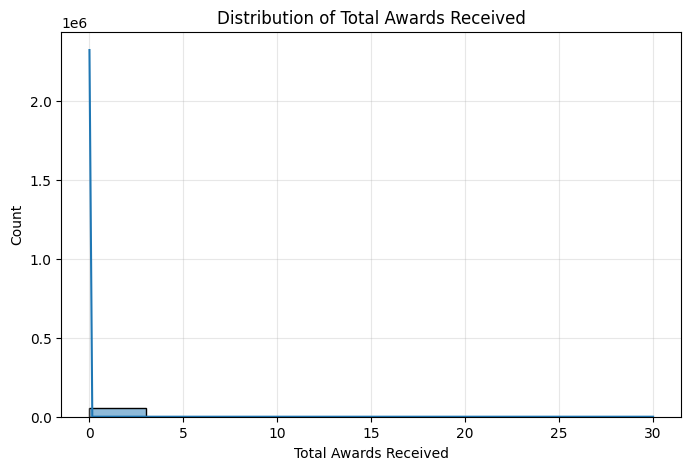

In [20]:
# Remove NaN or invalid values just in case
df['total_awards_received'] = pd.to_numeric(df['total_awards_received'], errors='coerce')
df_clean = df.dropna(subset=['total_awards_received'])

plt.figure(figsize=(8,5))
sns.histplot(df_clean['total_awards_received'], bins=10, kde=True)
plt.title('Distribution of Total Awards Received')
plt.xlabel('Total Awards Received')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

In [21]:
df.total_awards_received.fillna(0,inplace=True)

/tmp/ipykernel_20425/976138776.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.total_awards_received.fillna(0,inplace=True)


In [22]:
df.isnull().sum()

,0
id,0
title,0
score,0
author,0
author_flair_text,0
removed_by,0
total_awards_received,0
full_link,0
num_comments,0
over_18,0


Further Analysis

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert categorical to numeric if needed
df['over_18'] = df['over_18'].astype(int)
# df['is_deleted'] = df['removed_by'].notnull().astype(int)

# Select numeric columns for correlation
num_cols = ['score', 'num_comments', 'total_awards_received', 'over_18']
corr = df[num_cols].corr(method='pearson')
corr


,score,num_comments,total_awards_received,over_18
score,1.000000,0.597279,0.156223,0.018457
num_comments,0.597279,1.000000,0.168735,0.028543
total_awards_received,0.156223,0.168735,1.000000,0.005340
over_18,0.018457,0.028543,0.005340,1.000000


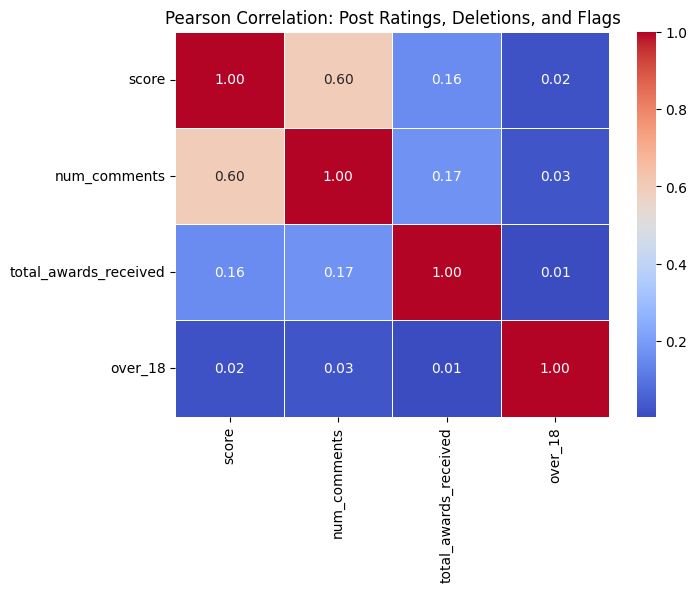

In [24]:
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation: Post Ratings, Deletions, and Flags")
plt.show()


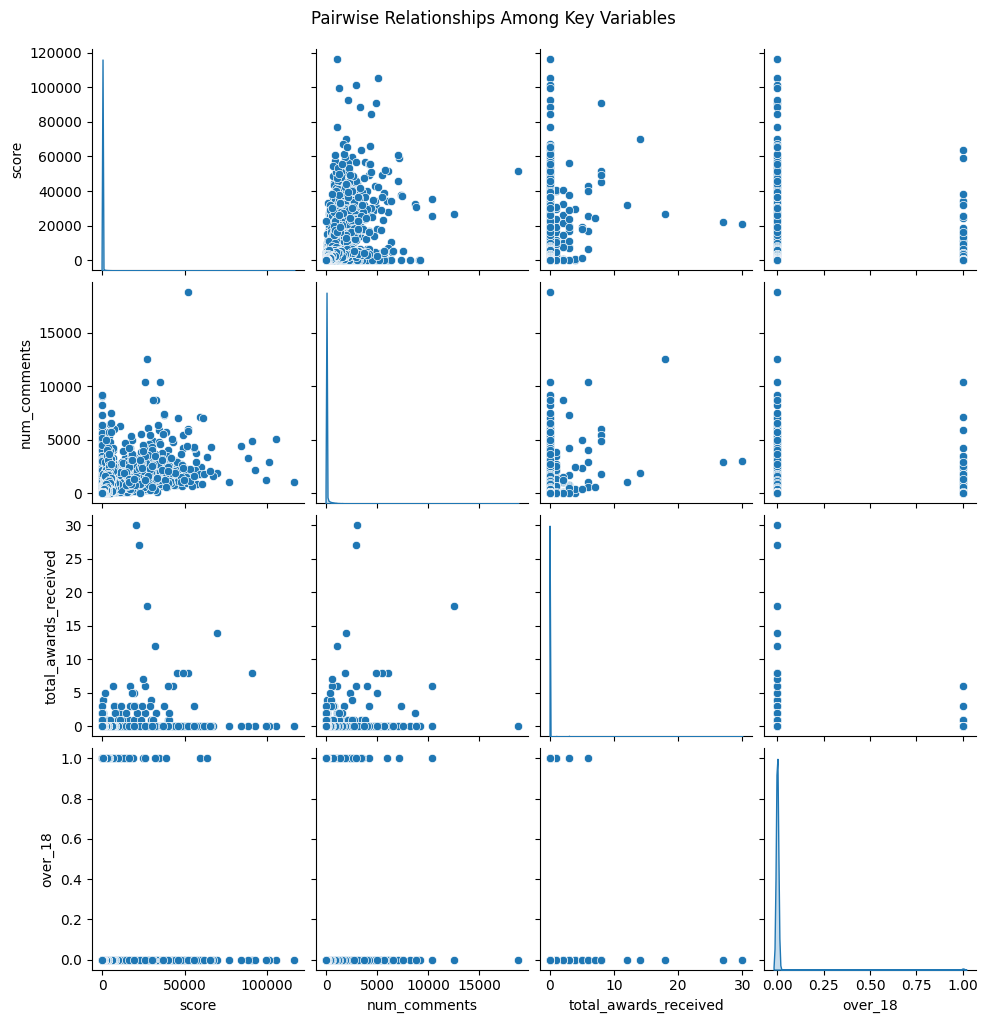

In [25]:
sns.pairplot(df[num_cols], diag_kind='kde')
plt.suptitle("Pairwise Relationships Among Key Variables", y=1.02)
plt.show()

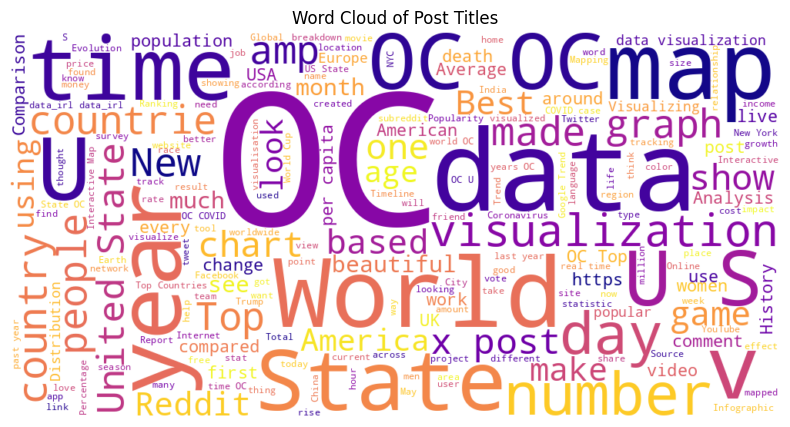

In [26]:
from wordcloud import WordCloud, STOPWORDS

text = " ".join(df['title'].dropna().astype(str))
wc = WordCloud(width=1000, height=500,
               background_color='white',
               stopwords=set(STOPWORDS),
               colormap='plasma').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Post Titles')
plt.show()

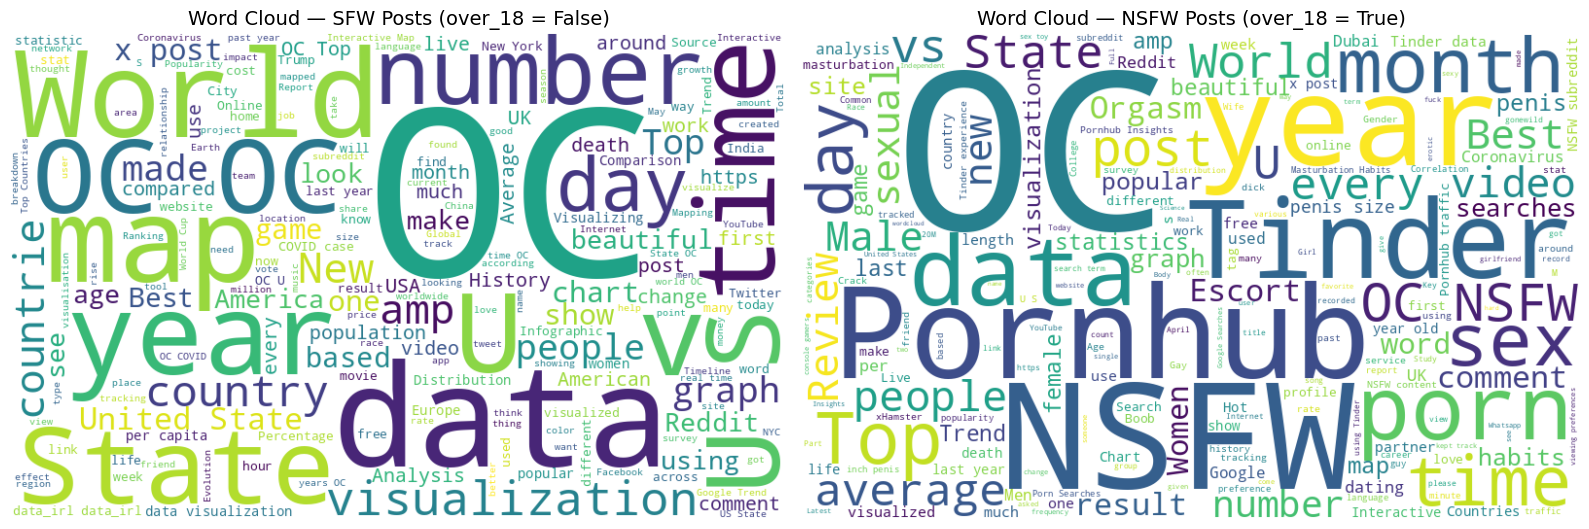

In [27]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Separate text for SFW and NSFW
sfw_text = " ".join(df[df['over_18'] == False]['title'].dropna().astype(str))
nsfw_text = " ".join(df[df['over_18'] == True]['title'].dropna().astype(str))

# Define common WordCloud settings
wc_params = {
    "width": 800,
    "height": 500,
    "background_color": "white",
    "stopwords": set(STOPWORDS),
    "colormap": "viridis"
}

# Generate both word clouds
wc_sfw = WordCloud(**wc_params).generate(sfw_text)
wc_nsfw = WordCloud(**wc_params).generate(nsfw_text)

# Plot side by side
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_sfw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — SFW Posts (over_18 = False)', fontsize=14)

plt.subplot(1, 2, 2)
plt.imshow(wc_nsfw, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — NSFW Posts (over_18 = True)', fontsize=14)

plt.tight_layout()
plt.show()


In [28]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Download resources
nltk.download('punkt')
nltk.download('stopwords')

# Text column
texts = df['title'].fillna("").astype(str)

# Cleaning
texts = texts.apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x.lower()))

# Tokenization
texts_tokenized = texts.apply(nltk.word_tokenize)

# Stopword removal
stop_words = set(stopwords.words('english')) | {"oc"}
texts_no_stop = texts_tokenized.apply(
    lambda tokens: [w for w in tokens if w not in stop_words]
)

# Stemming
stemmer = PorterStemmer()
texts_stemmed = texts_no_stop.apply(
    lambda tokens: [stemmer.stem(w) for w in tokens]
)

# Join back
texts_ready = texts_stemmed.apply(lambda tokens: " ".join(tokens))

# TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(texts_ready)

# Target
y = df['over_18'].astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check class distribution
print("Train set over_18 distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set over_18 distribution:")
print(y_test.value_counts(normalize=True))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Train set over_18 distribution:
over_18
0    0.994834
1    0.005166
Name: proportion, dtype: float64

Test set over_18 distribution:
over_18
0    0.994847
1    0.005153
Name: proportion, dtype: float64


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ----------------------------------------
# Decision Tree Classifier
# ----------------------------------------
dt = DecisionTreeClassifier(max_depth=100, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Metrics for Decision Tree
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)

print("----- Decision Tree Performance -----")
print(f"Accuracy : {acc_dt:.2f}")
print(f"Precision: {prec_dt:.2f}")
print(f"Recall   : {rec_dt:.2f}")
print(f"F1-Score : {f1_dt:.2f}\n")

# ----------------------------------------
# Random Forest Classifier
# ----------------------------------------
rf = RandomForestClassifier(n_estimators=300, max_depth=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics for Random Forest
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("----- Random Forest Performance -----")
print(f"Accuracy : {acc_rf:.2f}")
print(f"Precision: {prec_rf:.2f}")
print(f"Recall   : {rec_rf:.2f}")
print(f"F1-Score : {f1_rf:.2f}\n")

print("Detailed Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, zero_division=0))

----- Decision Tree Performance -----
Accuracy : 0.99
Precision: 0.33
Recall   : 0.14
F1-Score : 0.19

----- Random Forest Performance -----
Accuracy : 1.00
Precision: 0.69
Recall   : 0.06
F1-Score : 0.10

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     38419
           1       0.69      0.06      0.10       199

    accuracy                           1.00     38618
   macro avg       0.84      0.53      0.55     38618
weighted avg       0.99      1.00      0.99     38618



FIX :- HANDLE CLASS IMBALANCES
                                                                            
              Decision Tree + Random Forest with Class Weights


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# ----------------------------------------
# Decision Tree with Class Weights
# ----------------------------------------
dt = DecisionTreeClassifier(
    max_depth=100,
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt = f1_score(y_test, y_pred_dt, zero_division=0)

print("----- Decision Tree Performance -----")
print(f"Accuracy : {acc_dt:.2f}")
print(f"Precision: {prec_dt:.2f}")
print(f"Recall   : {rec_dt:.2f}")
print(f"F1-Score : {f1_dt:.2f}\n")

# ----------------------------------------
# Random Forest with Class Weights
# ----------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("----- Random Forest Performance -----")
print(f"Accuracy : {acc_rf:.2f}")
print(f"Precision: {prec_rf:.2f}")
print(f"Recall   : {rec_rf:.2f}")
print(f"F1-Score : {f1_rf:.2f}\n")

print("Detailed Classification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf, zero_division=0))

----- Decision Tree Performance -----
Accuracy : 0.98
Precision: 0.07
Recall   : 0.32
F1-Score : 0.12

----- Random Forest Performance -----
Accuracy : 0.99
Precision: 0.21
Recall   : 0.31
F1-Score : 0.25

Detailed Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     38419
           1       0.21      0.31      0.25       199

    accuracy                           0.99     38618
   macro avg       0.60      0.65      0.62     38618
weighted avg       0.99      0.99      0.99     38618



In [31]:
print("Model Comparison")
print(f"Decision Tree F1 Score : {f1_dt:.2f}")
print(f"Random Forest F1 Score : {f1_rf:.2f}")

Model Comparison
Decision Tree F1 Score : 0.12
Random Forest F1 Score : 0.25


In [32]:
import json

# ----------------------------------------
# Structured response schema
# ----------------------------------------
RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "nsfw_flag": {
            "type": "string",
            "enum": ["yes", "no"],
            "description": "Whether the Reddit post title is NSFW or sexually explicit."
        },
        "reason": {
            "type": "string",
            "description": "Short explanation for the classification."
        }
    },
    "required": ["nsfw_flag", "reason"]
}

# ----------------------------------------
# System prompt
# ----------------------------------------
SYSTEM_PROMPT = """
You are an AI content moderation assistant.

Your task is to determine whether a Reddit post title indicates NSFW (18+), sexually explicit, adult, or inappropriate content.

Rules:
1. Return only valid JSON.
2. The JSON must exactly follow this structure:
   {
     "nsfw_flag": "yes" or "no",
     "reason": "short explanation"
   }
3. Mark "yes" only if the title clearly suggests sexual, explicit adult, or NSFW content.
4. Mark "no" for safe, neutral, educational, analytical, or unrelated content.
5. Do not include markdown, code fences, or extra text outside JSON.
"""

# ----------------------------------------
# Function to create user prompt
# ----------------------------------------
def build_user_prompt(title: str) -> str:
    return f'Classify this Reddit post title: "{title}"'


# ----------------------------------------
# Example local fallback classifier
# (useful for testing without API call)
# ----------------------------------------
def simple_rule_based_nsfw_check(title: str) -> dict:
    nsfw_keywords = {
        "nsfw", "sex", "sexual", "nude", "naked", "porn", "adult",
        "explicit", "xxx", "erotic", "18+", "onlyfans"
    }

    title_lower = title.lower()

    found_keywords = [word for word in nsfw_keywords if word in title_lower]

    if found_keywords:
        return {
            "nsfw_flag": "yes",
            "reason": f"Title contains NSFW-related keyword(s): {', '.join(found_keywords)}"
        }
    else:
        return {
            "nsfw_flag": "no",
            "reason": "Title does not indicate sexually explicit or adult content."
        }


# ----------------------------------------
# Example usage
# ----------------------------------------
sample_titles = [
    "NSFW: explicit adult content warning",
    "Beautiful data visualization of global temperature change",
    "Top 10 erotic novels of the year",
    "Reddit post about income inequality"
]

for title in sample_titles:
    result = simple_rule_based_nsfw_check(title)
    print(f"Title: {title}")
    print(json.dumps(result, indent=2))
    print("-" * 50)

Title: NSFW: explicit adult content warning
{
  "nsfw_flag": "yes",
  "reason": "Title contains NSFW-related keyword(s): adult, nsfw, explicit"
}
--------------------------------------------------
Title: Beautiful data visualization of global temperature change
{
  "nsfw_flag": "no",
  "reason": "Title does not indicate sexually explicit or adult content."
}
--------------------------------------------------
Title: Top 10 erotic novels of the year
{
  "nsfw_flag": "yes",
  "reason": "Title contains NSFW-related keyword(s): erotic"
}
--------------------------------------------------
Title: Reddit post about income inequality
{
  "nsfw_flag": "no",
  "reason": "Title does not indicate sexually explicit or adult content."
}
--------------------------------------------------


In [33]:
!pip install -q google-generativeai

import google.generativeai as genai

genai.configure(api_key="YOUR_API_KEY")

model = genai.GenerativeModel("gemini-1.5-flash")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [40]:
import os
import google.generativeai as genai

# read API key from environment
api_key = os.getenv("GEMINI_API_KEY")

# configure Gemini
genai.configure(api_key=api_key)

# load model
model = genai.GenerativeModel("gemini-1.5-flash")

In [41]:
def call_model(title_text, config):

    response = model.generate_content(
        contents=title_text,
        generation_config=config
    )

    return response.text


In [36]:
import json

def process_title(title_text):

    config = {
        "response_mime_type": "application/json",
        "response_schema": RESPONSE_SCHEMA,
        "system_instruction": SYSTEM_PROMPT,
        "thinking_config": {"thinking_budget": 0}
    }

    try:
        raw_response = call_model(title_text, config)

        parsed = json.loads(raw_response)

        return parsed.get("nsfw_flag", "no")

    except Exception:
        return "no"


In [39]:
df_sample = df.iloc[:10,:].copy()
print(df_sample.head())
df_sample['nsfw_flag'] = df_sample['title'].apply(process_title)
print(df_sample[['title','nsfw_flag']].head())

       id                                              title  score  \
0  it7yz2                    [OC] The World’s Forests Mapped      1   
1  it7uig  [OC] Airbnb presence mapped in Barcelona (BCN)...      1   
2  it7t4z      A marketplace for open streaming data sources      1   
3  it7jfq                  [OC] Black Owner-Occupied Housing      1   
4  it7a3r  [OC] My monthly average steps in 2020. Quarant...      1   

              author author_flair_text        removed_by  \
0          vividmaps                         Not Removed   
1      JonnieNeptune             OC: 2       Not Removed   
2     DangerMouse289                    automod_filtered   
3  SocialExplorerInc            OC: 17       Not Removed   
4       ahmedgelemli             OC: 2       Not Removed   

   total_awards_received                                          full_link  \
0                    0.0  https://www.reddit.com/r/dataisbeautiful/comme...   
1                    0.0  https://www.reddit.com/r/dat

In [38]:
df_sample = df.iloc[:10,:].copy()

df_sample["nsfw_flag"] = df_sample["title"].apply(process_title)

print(df_sample[["title","nsfw_flag"]])

                                               title nsfw_flag
0                    [OC] The World’s Forests Mapped        no
1  [OC] Airbnb presence mapped in Barcelona (BCN)...        no
2      A marketplace for open streaming data sources        no
3                  [OC] Black Owner-Occupied Housing        no
4  [OC] My monthly average steps in 2020. Quarant...        no
5              [OC] #covid19 US county map animation        no
6                                      bibo vs shark        no
7  Here’s a map of the my toddlers decision makin...        no
8  [OC] Types of fuels used in cars in Belgium (2...        no
9  Here’s a map of the my toddlers decision makin...        no


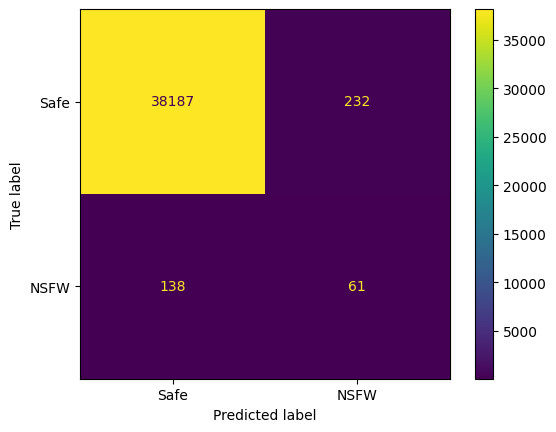

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Safe","NSFW"],
    cmap="viridis"
)